In [ ]:
import numpy as np 
import pandas as pd
import matplotlib.pyplot as plt
import torch 
import torch.nn as nn
import torch.nn.functional as F
from collections import Counter
import random
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction
import math 


[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\divya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


# Requirements for this task
1. Positional Encodings 
2. Scaled-Dot Product
3. Multihead Attention Class
4. Feed Forward Layer
5. Normalization Layer
6. Masked Multi Head Attention

In [31]:
# I have used LLM for syntax of a few functions and to handle sone dimension mismatches

In [3]:
def scaled_dot_product(q , k , v, mask):
    d_k = q.size()[-1] #dimension of queries = dimension of keys
    #here q k have dimesions --> (batch_size , sequence_length , dimension) , with .T(-1,-2) last two dimenstions are flipped
    scaled_dot = torch.matmul(q , k.transpose(-2 ,- 1)) / math.sqrt(d_k)
    if mask is not None:
        scaled_dot = scaled_dot.masked_fill(mask , float('-inf')) 
    attention = F.softmax(scaled_dot , dim = -1)
    values = torch.matmul(attention , v)
    return values , attention

In [4]:
class positional_encoding(nn.Module):
    def __init__(self, d_model , seq_len , dropout = 0.3):
        super().__init__()
        self.dropout = nn.Dropout(dropout)
        pe = torch.zeros(seq_len , d_model)   # seq_len x d_model   
        position = torch.arange(0 , seq_len).unsqueeze(1).float() # seq_len x 1
        factor = torch.exp(torch.arange(0, d_model, 2).float() * (-math.log(10000.0) / d_model))
        pe[: , 0::2] = torch.sin(position*factor)
        pe[: , 1::2] = torch.cos(position*factor)
        self.register_buffer('pe', pe.unsqueeze(0))  # (1, max_seq_len, d_model)
    def forward(self, x):
        x = x + self.pe[:, :x.size(1), :]
        return self.dropout(x)

In [5]:
class MultiheadAttention(nn.Module):
    def __init__(self, d_model , num_heads):
        super().__init__()
        self.d_model = d_model 
        self.num_heads = num_heads
        self.head_dim = d_model // num_heads  #in the original document the number of heads were 8 so we had dimension of 
        #each head as 512 / 8 = 64 
        #so we have 8 parallel layers after projecting original in 8 diff dimensions working on different part of input.
        self.W_q = nn.Linear(d_model , d_model)
        self.W_k = nn.Linear(d_model , d_model)
        self.W_v = nn.Linear(d_model , d_model)   #3 separate layers as the Q values come from decoder in decoder but K and V values come fron 
        #encoder (cross - attention)
        self.linear = nn.Linear(d_model , d_model)

    def forward( self , x , mask = None , context = None):
        
        batch_size , seq_len , d_model= x.size() #batch_size we get from the dataloader
        if context == None:
            context = x
        q = self.W_q(x).reshape(batch_size, seq_len, self.num_heads, self.head_dim).permute(0,2,1,3)  # batch x no. of head x target_len x head_dim
        k = self.W_k(context).reshape(batch_size, -1, self.num_heads, self.head_dim).permute(0,2,1,3) # batch x no. of head x seq_len x head_dim
        v = self.W_v(context).reshape(batch_size, -1, self.num_heads, self.head_dim).permute(0,2,1,3) # batch x no. of head x seq_len x head_dim
        values , attention = scaled_dot_product(q ,k ,v , mask)
        values = values.permute(0, 2, 1, 3).contiguous() 
        values = values.reshape(batch_size , seq_len , self.num_heads * self.head_dim)
        result = self.linear(values)
        return result

In [6]:
class feedforward(nn.Module):
    #creating a basic feed forward layer and forward pass function for it 
    
    def __init__(self, d_model, d_ff , dropout = 0.3):
        super().__init__()
        self.layers = nn.Sequential(
            nn.Linear(d_model , d_ff),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_ff , d_model)
        )
    def forward(self ,x):
        return self.layers(x)

In [7]:
class EncoderLayer(nn.Module):
    def __init__(self, d_model, num_head, d_ff , dropout = 0.3):
        super().__init__()
        self.attention = MultiheadAttention(d_model , num_head)
        self.fflayer = feedforward(d_model , d_ff , dropout)
        self.norm = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.dropout = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
    
    # Made on the basis of attention is all you need research paper

    def forward(self, x , mask = None):  
                                
        rem_x = x
        x = self.attention(x , mask = mask) 
        x = self.dropout(x)
        #Multihead attention layer , then normalization on output and residual 
        x = self.norm(rem_x + x)
        rem_x = x
        x = self.fflayer(x)
        #Feed Forward layer , then normalization on output and residual 
        x = self.dropout2(x)
        x = self.norm2(rem_x + x)
        return x

In [8]:
class Encoder(nn.Module):
    def __init__(self , d_model , seq_len , d_ff , num_head , num_layers , dropout = 0.3):
        super().__init__()
        self.input_proj = nn.Linear(1,d_model)
        self.pos_encoding = positional_encoding(d_model , seq_len , dropout)
        self.layers = nn.Sequential(*[EncoderLayer(d_model , num_head , d_ff , dropout)
                                    for i in range(num_layers)])
        self.final = nn.Linear(d_model , 10)
    def forward(self,x):
        x = self.input_proj(x)
        x = self.pos_encoding(x)
        x = self.layers(x)
        x = self.final(x)
        return x

In [ ]:
def padding_mask(seq , pad_index = 0):
    return (seq == pad_index).unsqueeze(1).unsqueeze(2)
def make_causal_mask(seq_len):
    # returns (seq_len, seq_len) — upper triangle is masked
    mask = torch.tril(torch.ones(seq_len, seq_len)).bool()
    return ~mask


In [ ]:
class DecoderLayer(nn.Module):
    def __init__(self , d_model , num_head , d_ff , dropout = 0.3):
        super().__init__()
        self.attention1 = MultiheadAttention(d_model , num_head) #masked self attention 
        self.attention2 = MultiheadAttention(d_model , num_head) #cross attention layer
        self.fflayer = feedforward(d_model , d_ff , dropout = dropout)
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.norm3 = nn.LayerNorm(d_model)
        self.dropout1 = nn.Dropout(dropout)
        self.dropout2 = nn.Dropout(dropout)
        self.dropout3 = nn.Dropout(dropout)

    def forward(self ,  x , encoder_output , seq_mask , target_mask):
        rem_x = x #for adding the original to the rsidual while normalizing
        x = self.attention1(x , mask = target_mask) #self attention layer
        x = self.dropout1(x)
        x = self.norm1(x + rem_x)
        rem_x = x
        x = self.attention2(x , mask = seq_mask , context = encoder_output) # cross attention layer where the Q values come from decider
        #but the k and v values come from encoder
        x = self.dropout2(x)
        x = self.norm2(x + rem_x) 
        rem_x = x
        x = self.fflayer(x)
        x = self.dropout3(x)
        x = self.norm3(x + rem_x)
        return x


In [ ]:
# LLM used for syntax
class transformer(nn.Module):
    def __init__(self, vocab_size , d_model , seq_len , d_ff , num_head , num_layers , dropout = 0.3):
        super().__init__()
        self.seq_emb = nn.Embedding(vocab_size , d_model)
        self.target_emb = nn.Embedding(vocab_size , d_model)
        self.pos_encoding = positional_encoding( d_model , seq_len , dropout = 0.3) #positional encoding
        self.enc = nn.ModuleList([EncoderLayer(d_model , num_head, d_ff , dropout) for i in range(num_layers)]) 
        self.dec = nn.ModuleList([DecoderLayer(d_model , num_head , d_ff , dropout ) for i in range(num_layers)])
        self.fc = nn.Linear(d_model , vocab_size)
        self.dropout = nn.Dropout(dropout)
    def forward(self, seq , target):
        seq_mask = padding_mask(seq)
        #masking the target matrice
        target_mask_pad = padding_mask(target)
        target_causal_mask = make_causal_mask(target.shape[1]).to(target.device)
        target_mask = target_mask_pad | target_causal_mask #tkaes whatever mask is true , takes if both are true as well
        seq = self.seq_emb(seq)
        target = self.target_emb(target)
        seq = self.pos_encoding(seq) # applying positional encoding to both
        target = self.pos_encoding(target)
        x = seq
        for layer in self.enc:
            x = layer( x,mask = seq_mask )
        encoder_output = x
        x = target
        for layer in self.dec:
            x = layer(x , encoder_output , seq_mask , target_mask)

        return self.fc(x)



In [ ]:
#training loop
def train_transformer(model , train_data , val_data , epochs = 20):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    model = model.to(device)
    optimizer = torch.optim.Adam(model.parameters() , lr = 1e-5 , weight_decay= 1e-6)
    lossfnx = nn.CrossEntropyLoss(ignore_index= 0 )
    loss_train = []
    loss_val = []
    for epoch in range(epochs):
        model.train()
        total_loss_train = 0
        for seq , target in train_data:
            optimizer.zero_grad()
            seq , target = seq.to(device) , target.to(device)
            pred = model(seq, target[:, :-1])         
            #LLM used for dimension matching
            output_dim = pred.shape[-1]
            predict_flattened = pred.reshape(-1, output_dim)     
            target_flattened = target[:, 1:].reshape(-1)        
            loss = lossfnx(predict_flattened, target_flattened)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            total_loss_train+=loss.item()
            optimizer.step()

        loss_train.append(total_loss_train/len(train_data))

        model.eval()
        with torch.no_grad():
            total_loss_val = 0
            for seq , target in val_data:
                seq , target = seq.to(device ) , target.to(device)
                predict = model(seq , target)
                output_dim = predict.shape[-1]
                predict_flattened = predict[:, 1:].reshape(-1, output_dim)
                target_flattened = target[:, 1:].reshape(-1)
                loss = lossfnx(predict_flattened , target_flattened)
                total_loss_val+=loss.item()
            loss_val.append(total_loss_val/len(val_data))
        
        print(f"For Epoch {epoch+1} Training Loss: {total_loss_train/len(train_data):.2f} Validation Loss: {total_loss_val/len(val_data):.2f}")

    return loss_train , loss_val 

In [13]:
df = pd.read_csv("code.csv")

In [14]:
bugged = df["buggy"].to_list()
fixed = df['fixed'].to_list()

In [15]:
# data preprocessing --> tokenization and padding
from collections import Counter
def tokenize(code):
    return code.split()
all_token = []
total_codes = bugged + fixed
for code in total_codes:
    all_token.extend(tokenize(code))

vocab = Counter(all_token)

word_idx = {"<pad>" : 0 , "<sos>" : 1 , "<eos>" : 2 , "<unk>" : 3}
for word , count in vocab.items():
    if count>=2:
        word_idx[word] = len(word_idx)

idx_word = {v: k for k ,v in word_idx.items()}

def encode_seq(code , word_idx , max_len = 80):
    tokens = ["<sos>"] + tokenize(code) + ["<eos>"]
    tokens = tokens[:max_len]
    ids = [word_idx.get(t , word_idx["<unk>"]) for t in tokens]
    ids+=[word_idx["<pad>"]] * ( max_len - len(ids))
    return ids

bugged_enc = [encode_seq(c,word_idx) for c in bugged]
fixed_enc = [encode_seq(c,word_idx) for c in fixed]

In [16]:
# creating dataset and dataloader
from torch.utils.data import Dataset, DataLoader
class Data(Dataset):
    def __init__(self , seq , target ):
        self.seq = torch.tensor(seq , dtype = torch.long)
        self.target = torch.tensor(target , dtype = torch.long)
    def __len__(self):
        return len(self.seq)
    def __getitem__(self , idx):
        return self.seq[idx] , self.target[idx]
train_data = DataLoader(Data(bugged_enc,fixed_enc) , batch_size = 256 , shuffle =True)
val_data = DataLoader(Data(bugged_enc,fixed_enc) , batch_size = 256)

In [17]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
model = transformer(
    vocab_size=len(word_idx),
    d_model=64,
    seq_len=128,
    d_ff=128,
    num_head=4,
    num_layers=2,
    dropout=0.7
).to(device)
epoch = 20 
total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Total parameters: {total_params:,}")


Total parameters: 262,187


In [18]:
loss_train , loss_val = train_transformer(model , train_data , val_data , epochs = epoch) 

For Epoch 1 Training Loss: 6.18 Validation Loss: 5.60
For Epoch 2 Training Loss: 5.84 Validation Loss: 5.18
For Epoch 3 Training Loss: 5.52 Validation Loss: 4.91
For Epoch 4 Training Loss: 5.25 Validation Loss: 4.71
For Epoch 5 Training Loss: 5.03 Validation Loss: 4.55
For Epoch 6 Training Loss: 4.85 Validation Loss: 4.41
For Epoch 7 Training Loss: 4.69 Validation Loss: 4.30
For Epoch 8 Training Loss: 4.55 Validation Loss: 4.20
For Epoch 9 Training Loss: 4.42 Validation Loss: 4.12
For Epoch 10 Training Loss: 4.32 Validation Loss: 4.05
For Epoch 11 Training Loss: 4.23 Validation Loss: 4.00
For Epoch 12 Training Loss: 4.15 Validation Loss: 3.96
For Epoch 13 Training Loss: 4.08 Validation Loss: 3.92
For Epoch 14 Training Loss: 4.02 Validation Loss: 3.90
For Epoch 15 Training Loss: 3.96 Validation Loss: 3.88
For Epoch 16 Training Loss: 3.91 Validation Loss: 3.88
For Epoch 17 Training Loss: 3.85 Validation Loss: 3.88
For Epoch 18 Training Loss: 3.79 Validation Loss: 3.90
For Epoch 19 Traini

In [19]:
# training dataset
from sklearn.model_selection import train_test_split
X_train , X_test , y_train , y_test = train_test_split(

    bugged,
    fixed,
    test_size = 0.1,
    random_state= 42
)

In [20]:
def predict_transformer(model , codes , word_idx , idx_word , max_len = 80 , device = 'cuda'):
    model.eval()
    results = []
    with torch.no_grad():
        for code in codes:
            geenrated = []
            tokens = encode_seq(code , word_idx , max_len)
            seq = torch.tensor(tokens).unsqueeze(0).to(device)  
            target = torch.tensor([[word_idx["<sos>"]]]).to(device)
            for _ in range(max_len):
                pred = model(seq , target)
                next = pred[: , -1 , :].argmax(dim = -1)
                if next.item() == word_idx["<eos>"]:
                    break
                target = torch.cat([target , next.unsqueeze(0)] , dim = 1)
            geenrated = [idx_word.get(t.item() , "<unk>") for t in target[0 , 1:]]
            results.append(" ".join(geenrated))
        return results

In [21]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
results = predict_transformer(model , X_test , word_idx , idx_word , 80 , device)

In [26]:
print(y_test[2])
print(results[2])

public static void METHOD_1 ( android.content.Context context ) throws java.io.IOException , TYPE_1 , TYPE_2 { TYPE_3 . METHOD_2 ( context ) ; VAR_1 = TYPE_3 . METHOD_4 ( ) ; try ( TYPE_4 VAR_2 = new TYPE_5 ( context ) ) { ( ( TYPE_5 ) ( VAR_2 ) ) . METHOD_5 ( ) ; for ( TYPE_6 VAR_3 : VAR_1 ) { ( ( TYPE_5 ) ( VAR_2 ) ) . METHOD_6 ( VAR_3 ) ; } } catch ( java.lang.Exception VAR_4 ) { } }

public ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; ( ) ; } ( ) ; ( ) ; ( ) ; } ( ) ; } (


In [27]:
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3050 6GB Laptop GPU


In [28]:
def token_accuracy(predictions, references):
    total_tokens = 0
    correct_tokens = 0
    
    for pred, ref in zip(predictions, references):
        pred_tokens = pred.split()
        ref_tokens = ref.split()
        
        # compare up to the length of the shorter sequence
        min_len = min(len(pred_tokens), len(ref_tokens))
        correct_tokens += sum(1 for i in range(min_len) if pred_tokens[i] == ref_tokens[i])
        total_tokens += len(ref_tokens)
    
    accuracy = correct_tokens / total_tokens
    print(f"Token Accuracy (%): {accuracy*100:.2f}")
    return accuracy

token_accuracy(results , y_test)
print()

Token Accuracy (%): 11.89



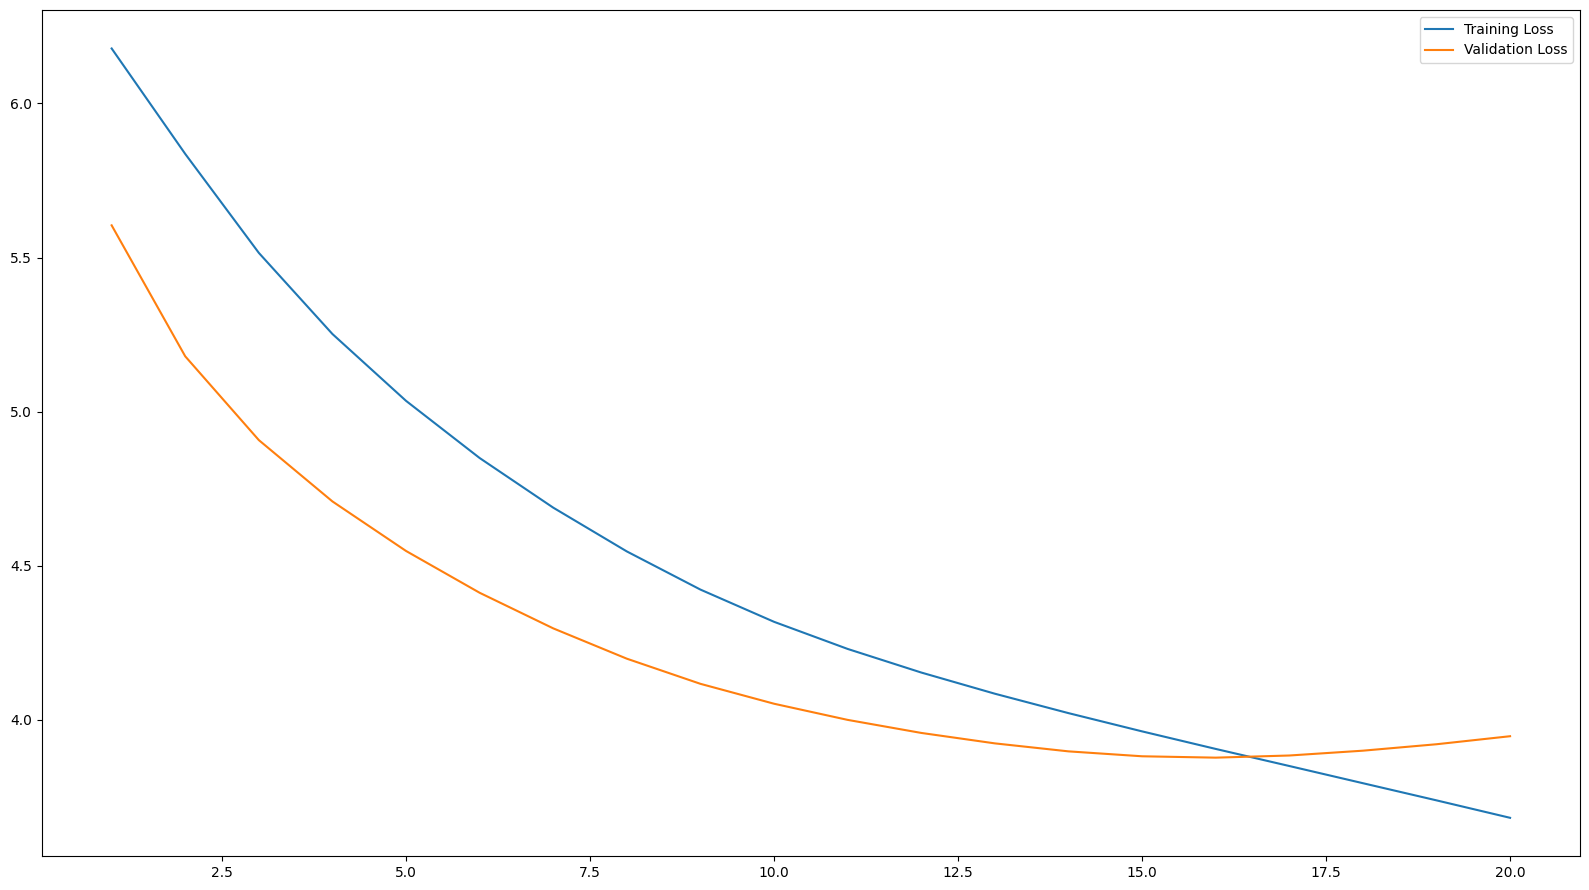

In [29]:
plt.figure(figsize = (16,9))
x = np.arange(1 , epoch+1)
plt.plot(x , loss_train , label = "Training Loss")
plt.plot(x , loss_val , label = "Validation Loss")
plt.legend()
plt.tight_layout()
plt.savefig("T&VEncDecTsfm.png")

In [30]:
#BLEU SCORE 
# LLM for writing this function 
import nltk
nltk.download('punkt')
from nltk.translate.bleu_score import corpus_bleu, sentence_bleu, SmoothingFunction

def evaluate_bleu(predictions, references):
    smoothing = SmoothingFunction().method1
    
    # corpus level BLEU
    refs = [[ref.split()] for ref in references]
    hyps = [pred.split() for pred in predictions]
    
    bleu1 = corpus_bleu(refs, hyps, weights=(1,0,0,0))
    bleu2 = corpus_bleu(refs, hyps, weights=(0.5,0.5,0,0))
    bleu4 = corpus_bleu(refs, hyps, weights=(0.25,0.25,0.25,0.25))
    
    print(f"BLEU-1: {bleu1:.4f}")
    print(f"BLEU-2: {bleu2:.4f}")
    print(f"BLEU-4: {bleu4:.4f}")
    
    return bleu1, bleu2, bleu4

# usage
bleu1, bleu2, bleu4 = evaluate_bleu(results, y_test)

[nltk_data] Downloading package punkt to
[nltk_data]     C:\Users\divya\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt is already up-to-date!


BLEU-1: 0.3627
BLEU-2: 0.1974
BLEU-4: 0.0467
